In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("../data/raw/train_2.csv", encoding="utf-8")
df = df.sort_values(['new_id', 'Год', 'Месяц'])
df

,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,...,"Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,7.491475e+07
5,0,2023,2,1.37,5.89,118.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,6.924000e+07
7,0,2023,3,1.34,5.87,236.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,7.990573e+07
9,0,2023,4,1.55,5.89,174.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,7.856764e+07
11,0,2023,5,1.79,5.70,218.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,8.085617e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485076,21745,2024,10,0.84,6.11,1584.0,9.0,Средний по возрасту,Большой,Павловский Посад г,...,204,5,2,2,4,3,3,13,1,2.125847e+08
485078,21745,2024,11,0.91,6.21,1226.0,9.0,Средний по возрасту,Большой,Павловский Посад г,...,204,5,2,2,4,3,3,13,1,2.074941e+08
485081,21745,2024,12,0.98,6.38,1170.0,9.0,Средний по возрасту,Большой,Павловский Посад г,...,204,5,2,2,4,3,3,13,1,2.428249e+08
485057,21745,2025,1,0.78,6.13,1065.0,9.0,Средний по возрасту,Большой,Павловский Посад г,...,204,5,2,2,4,3,3,13,1,2.105818e+08


In [20]:
df.columns

Index(['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке',
       'Среднее количество товаров в чеке', 'Среднее количество отмен',
       'Рабочие часы в день', 'Дата открытия, категориальный',
       'Торговая площадь, категориальный', 'Населенный пункт', 'Регион',
       'Численность населения', 'Количество домохозяйств',
       'Трафик пеший, в час', 'Трафик авто, в час',
       'Маркетплейсы, доставки, постаматы (100 м)',
       'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)',
       'Остановки (300 м)', 'Продуктовые магазины (500 м)',
       'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии',
       'РТО'],
      dtype='str')

In [21]:
df_grouped = df.groupby("new_id")

print(f"Наблюдений для каждого магазина и кол-во магазинов:")
print(df_grouped['РТО'].count().value_counts())

Наблюдений для каждого магазина и кол-во магазинов:
РТО
26    18657
Name: count, dtype: int64


In [22]:
df['Флаг алкогольной лицензии'].value_counts()

Флаг алкогольной лицензии
1    451308
0     33774
Name: count, dtype: int64

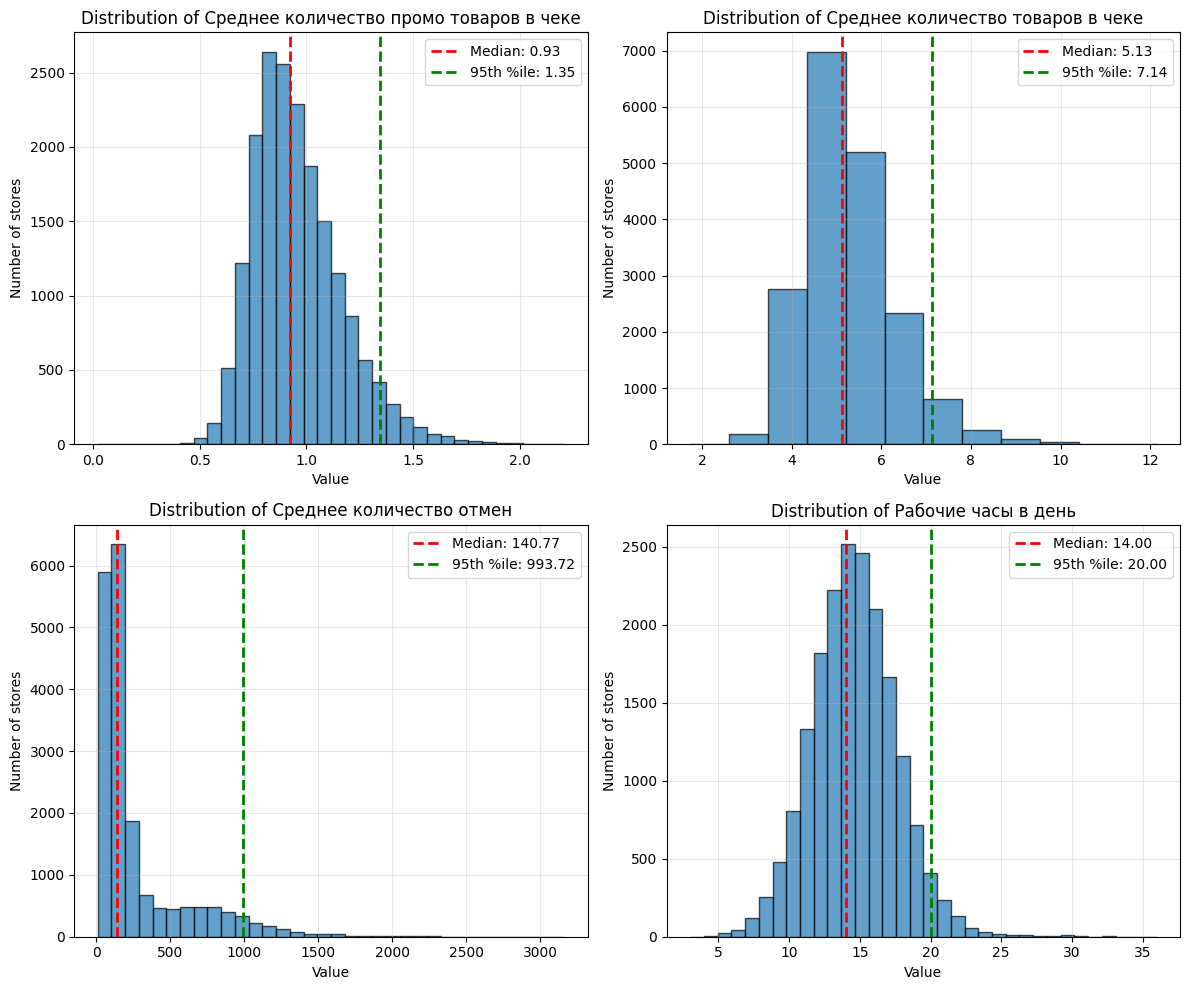

In [23]:
# Plot distributions of specified columns for df_grouped
columns_to_plot = [
    'Среднее количество промо товаров в чеке',
    'Среднее количество товаров в чеке',
    'Среднее количество отмен',
    'Рабочие часы в день'
]

# Group and aggregate
grouped_stats = df_grouped[columns_to_plot].mean()

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, col in enumerate(columns_to_plot):
    num_bins = min(34, round(grouped_stats[col].max()))
    if num_bins <= 2:
        num_bins = 34
    axes[idx].hist(grouped_stats[col], bins=num_bins, edgecolor='black', alpha=0.7)
    
    # Add median and 95% percentile lines
    median_val = grouped_stats[col].median()
    percentile_95_val = grouped_stats[col].quantile(0.95)
    
    axes[idx].axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[idx].axvline(percentile_95_val, color='green', linestyle='--', linewidth=2, label=f'95th %ile: {percentile_95_val:.2f}')
    
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Number of stores')
    axes[idx].grid(alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.show()

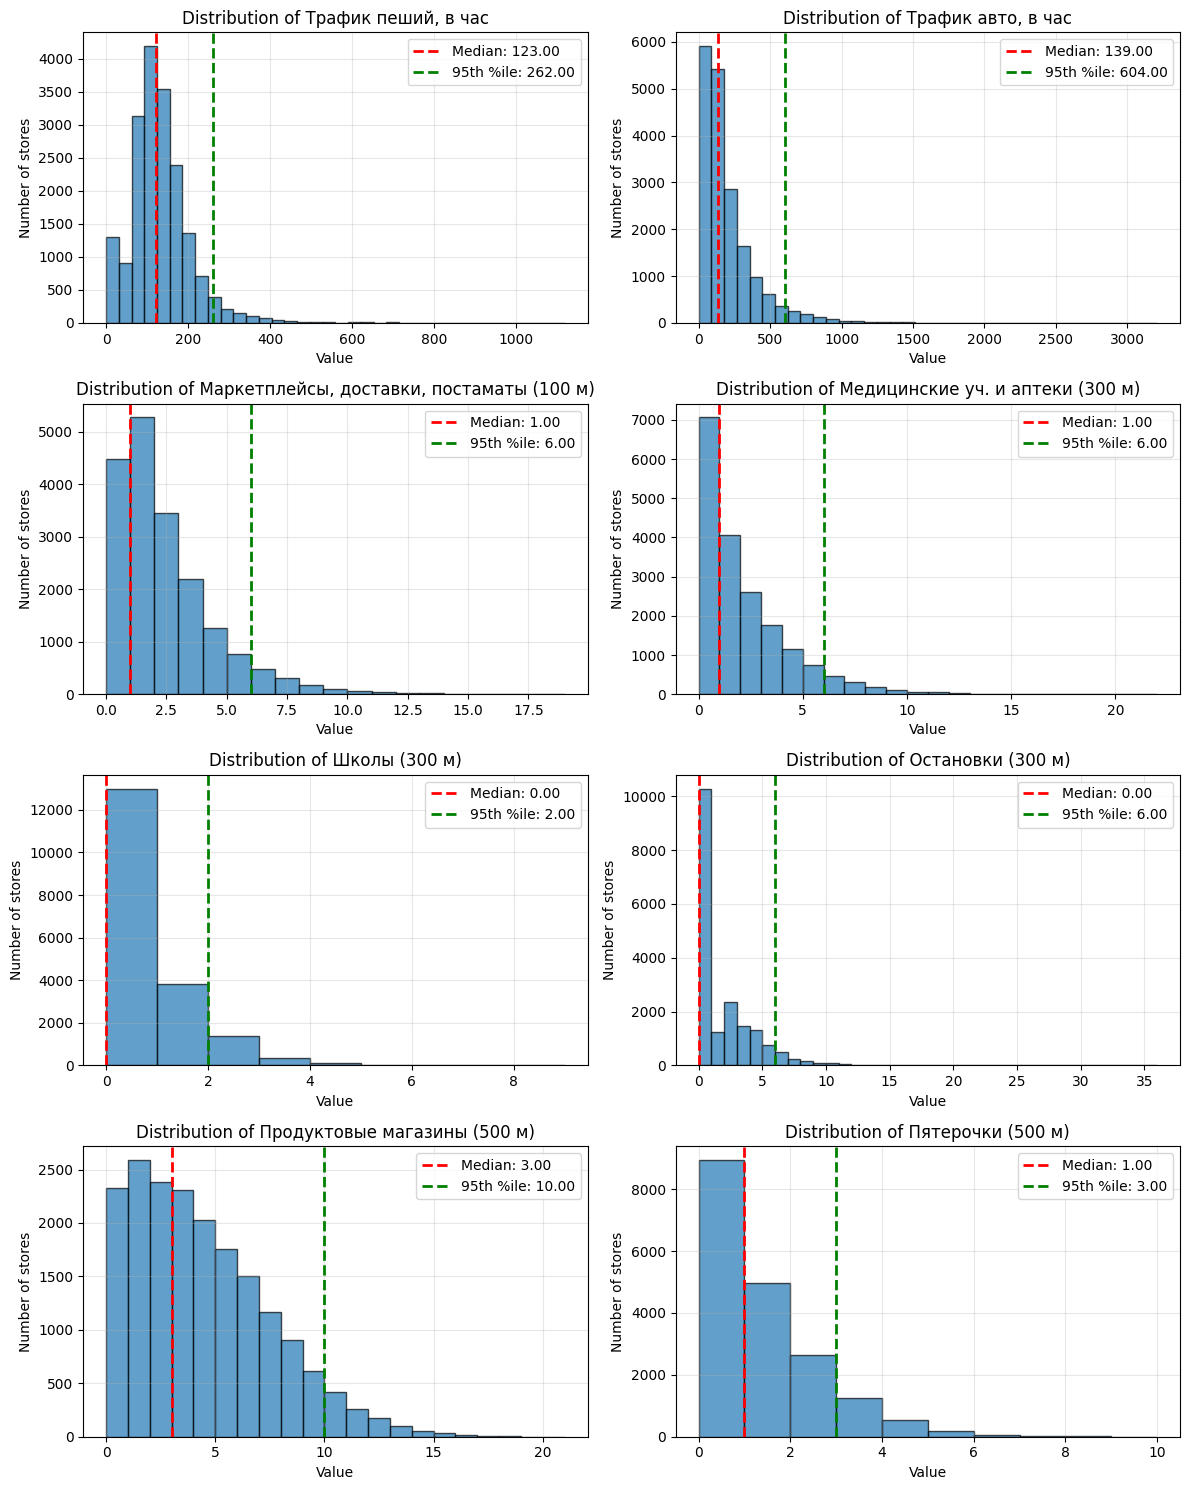

In [24]:
columns_to_plot = [
       'Трафик пеший, в час', 'Трафик авто, в час',
       'Маркетплейсы, доставки, постаматы (100 м)',
       'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)',
       'Остановки (300 м)', 'Продуктовые магазины (500 м)',
       'Пятерочки (500 м)'
]

# Group and aggregate
grouped_stats = df_grouped[columns_to_plot].mean()

# Create subplots
fig, axes = plt.subplots(4, 2, figsize=(12, 15))
axes = axes.flatten()

for idx, col in enumerate(columns_to_plot):
    num_bins = min(36, round(grouped_stats[col].max()))
    axes[idx].hist(grouped_stats[col], bins=num_bins, edgecolor='black', alpha=0.7)
    
    # Add median and 95% percentile lines
    median_val = grouped_stats[col].median()
    percentile_95_val = grouped_stats[col].quantile(0.95)
    
    axes[idx].axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[idx].axvline(percentile_95_val, color='green', linestyle='--', linewidth=2, label=f'95th %ile: {percentile_95_val:.2f}')
    
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Number of stores')
    axes[idx].grid(alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.show()

### Среднее количество отмен в месяц и Количество касс имеют высокую корреляцию с РТО

In [25]:
# Calculate correlation between numeric variables and РТО
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
correlations = df[numeric_cols].corr()['РТО'].sort_values(ascending=False)
print("Correlation with РТО:")
print(correlations)

Correlation with РТО:
РТО                                          1.000000
Среднее количество отмен                     0.722502
Количество касс                              0.627470
Среднее количество товаров в чеке            0.368638
Численность населения                        0.351143
Среднее количество промо товаров в чеке      0.234716
Количество домохозяйств                      0.215092
Маркетплейсы, доставки, постаматы (100 м)    0.212457
Остановки (300 м)                            0.211887
Трафик пеший, в час                          0.166888
Медицинские уч. и аптеки (300 м)             0.154277
Год                                          0.107290
Рабочие часы в день                          0.102206
Школы (300 м)                                0.086799
Месяц                                        0.076946
Трафик авто, в час                           0.028052
Флаг алкогольной лицензии                    0.014413
Продуктовые магазины (500 м)                 0.001938
new_id

### В Богатых регионах РТО в среднем выше
(Ямало-Ненецкий АО один из самых богатых регионов из-за добычи газа)

In [26]:
df.groupby("Регион")['РТО'].mean().sort_values()

Регион
Северная Осетия - Алания Респ    5.131630e+07
Ульяновская обл                  5.521126e+07
Мордовия Респ                    5.541937e+07
Пензенская обл                   5.931288e+07
Хакасия Респ                     6.017834e+07
                                     ...     
Московская обл                   1.148284e+08
Ленинградская обл                1.152509e+08
Москва г                         1.460176e+08
Ямало-Ненецкий АО                1.517359e+08
Санкт-Петербург г                1.528715e+08
Name: РТО, Length: 67, dtype: float64

### В Старых магазинах РТО относительно высокий. Новый и средний по возрасту вообще не отличаются.

In [27]:
df.groupby('Дата открытия, категориальный')['РТО'].mean().sort_values()

Дата открытия, категориальный
Новый                  8.516327e+07
Средний по возрасту    8.526652e+07
Открыт давно           1.524001e+08
Name: РТО, dtype: float64

### Площадь значительно коррелирует с РТО

In [28]:
df.groupby('Торговая площадь, категориальный')['РТО'].mean().sort_values()

Торговая площадь, категориальный
Маленький        6.524946e+07
Средний          8.006413e+07
Большой          1.210444e+08
Очень большой    1.963988e+08
Name: РТО, dtype: float64

In [29]:
# Порядковый номер месяца внутри каждого магазина (1..26)
df_yoy = df.copy()
df_yoy['month_seq'] = df_yoy.groupby('new_id').cumcount() + 1

# РТО за тот же месяц предыдущего года
df_yoy['РТО_prev_year'] = df_yoy.groupby('new_id')['РТО'].shift(12)

# Оставляем только те строки, для которых есть данные год назад (month_seq >= 13)
df_yoy = df_yoy[df_yoy['month_seq'] >= 13].copy()

# Вычисляем изменение (процентное)
df_yoy['change_yoy'] = (df_yoy['РТО'] - df_yoy['РТО_prev_year']) / df_yoy['РТО_prev_year'] * 100

# Группируем по году и месяцу
avg_change = df_yoy.groupby(['Год', 'Месяц'])['change_yoy'].mean().reset_index()

print("Среднее изменение РТО год к году для каждого месяца:\n")
print(avg_change)

Среднее изменение РТО год к году для каждого месяца:

     Год  Месяц  change_yoy
0   2024      1   19.559812
1   2024      2   20.952139
2   2024      3   18.691736
3   2024      4   15.998029
4   2024      5   16.293843
5   2024      6   16.856968
6   2024      7   16.717523
7   2024      8   13.955409
8   2024      9   13.233814
9   2024     10   13.846434
10  2024     11   14.547736
11  2024     12   13.395162
12  2025      1   15.429048
13  2025      2    9.802776


In [30]:
df[df['Рабочие часы в день'] > 24].head(30)

,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,...,"Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
3200,136,2023,1,1.43,6.70,129.0,26.0,Открыт давно,Средний,Москва г,...,299,2,5,0,4,6,3,6,1,57781095.48
3201,136,2023,2,1.34,6.18,68.0,26.0,Открыт давно,Средний,Москва г,...,299,2,5,0,4,6,3,6,1,56534402.67
3205,136,2023,3,1.40,5.69,104.0,26.0,Открыт давно,Средний,Москва г,...,299,2,5,0,4,6,3,6,1,63539221.67
3206,136,2023,4,1.45,5.52,111.0,26.0,Открыт давно,Средний,Москва г,...,299,2,5,0,4,6,3,6,1,58546370.51
3209,136,2023,5,1.38,5.68,95.0,26.0,Открыт давно,Средний,Москва г,...,299,2,5,0,4,6,3,6,1,53608122.52
3211,136,2023,6,1.22,5.37,109.0,26.0,Открыт давно,Средний,Москва г,...,299,2,5,0,4,6,3,6,1,49019083.42
3212,136,2023,7,1.43,5.54,120.0,26.0,Открыт давно,Средний,Москва г,...,299,2,5,0,4,6,3,6,1,40386092.24
3214,136,2023,8,0.81,4.82,240.0,26.0,Открыт давно,Средний,Москва г,...,299,2,5,0,4,6,3,6,1,28379771.75
3217,136,2023,9,1.09,5.56,183.0,26.0,Открыт давно,Средний,Москва г,...,299,2,5,0,4,6,3,6,1,41664298.38
3219,136,2023,10,0.98,5.61,198.0,26.0,Открыт давно,Средний,Москва г,...,299,2,5,0,4,6,3,6,1,45360289.04


### У магазинов, которые работают >24 часов в сутки, нет ничего общего. Возможно кто-то ошибся и написал 2 вместо 1 в первой цифре. Однако это не объясняет 35 и 36

In [31]:
filtered = df[df['Рабочие часы в день'] > 24]

if filtered.empty:
    print("Нет записей с Рабочие часы в день > 24")
else:
    constant_cols = []
    for col in filtered.columns:
        # Пропускаем колонку-фильтр
        if col == 'Рабочие часы в день':
            continue
        if filtered[col].nunique() == 1:
            constant_cols.append(col)
    
    print("Колонки с одинаковым значением при Рабочие часы > 24:")
    for col in constant_cols:
        print(f"  {col}: {filtered[col].iloc[0]}")
    
    if not constant_cols:
        print("Таких колонок не найдено.")

Колонки с одинаковым значением при Рабочие часы > 24:
Таких колонок не найдено.


### У других аномалий также нет ничего общего. Однако если аномалия присутствует для магазина, то она присутствует для всех его записей

In [32]:
columns_to_check = [
    'Трафик пеший, в час',
    'Трафик авто, в час',
    'Маркетплейсы, доставки, постаматы (100 м)',
    'Медицинские уч. и аптеки (300 м)',
    'Школы (300 м)',
    'Остановки (300 м)',
    'Продуктовые магазины (500 м)',
    'Пятерочки (500 м)'
]

for col in columns_to_check:
    print(f"\n=== Анализ колонки: {col} ===")
    
    # Вычисляем 99-й перцентиль
    percentile_99 = df[col].quantile(0.99)
    print(f"99-й перцентиль: {percentile_99}")
    
    # Фильтруем строки, где значение > 99-го перцентиля
    filtered = df[df[col] > percentile_99]
    print(f"Количество записей с {col} > 99-го перцентиля: {len(filtered)}, делится на 26: {len(filtered) % 26 == 0}")
    
    if filtered.empty:
        print("Нет записей, удовлетворяющих условию.")
        continue
    
    # Ищем колонки с постоянным значением в отфильтрованных данных
    constant_cols = []
    for other_col in df.columns:
        if other_col == col:
            continue
        if filtered[other_col].nunique() == 1:
            constant_cols.append(other_col)
    
    if constant_cols:
        print("Колонки, имеющие одинаковое значение в отфильтрованных записях:")
        for const_col in constant_cols:
            print(f"  {const_col}: {filtered[const_col].iloc[0]}")
    else:
        print("Нет колонок с одинаковым значением в отфильтрованных записях.")


=== Анализ колонки: Трафик пеший, в час ===
99-й перцентиль: 407.0
Количество записей с Трафик пеший, в час > 99-го перцентиля: 4784, делится на 26: True
Нет колонок с одинаковым значением в отфильтрованных записях.

=== Анализ колонки: Трафик авто, в час ===
99-й перцентиль: 1000.0
Количество записей с Трафик авто, в час > 99-го перцентиля: 4810, делится на 26: True
Нет колонок с одинаковым значением в отфильтрованных записях.

=== Анализ колонки: Маркетплейсы, доставки, постаматы (100 м) ===
99-й перцентиль: 9.0
Количество записей с Маркетплейсы, доставки, постаматы (100 м) > 99-го перцентиля: 4680, делится на 26: True
Нет колонок с одинаковым значением в отфильтрованных записях.

=== Анализ колонки: Медицинские уч. и аптеки (300 м) ===
99-й перцентиль: 10.0
Количество записей с Медицинские уч. и аптеки (300 м) > 99-го перцентиля: 3250, делится на 26: True
Нет колонок с одинаковым значением в отфильтрованных записях.

=== Анализ колонки: Школы (300 м) ===
99-й перцентиль: 3.0
Количе

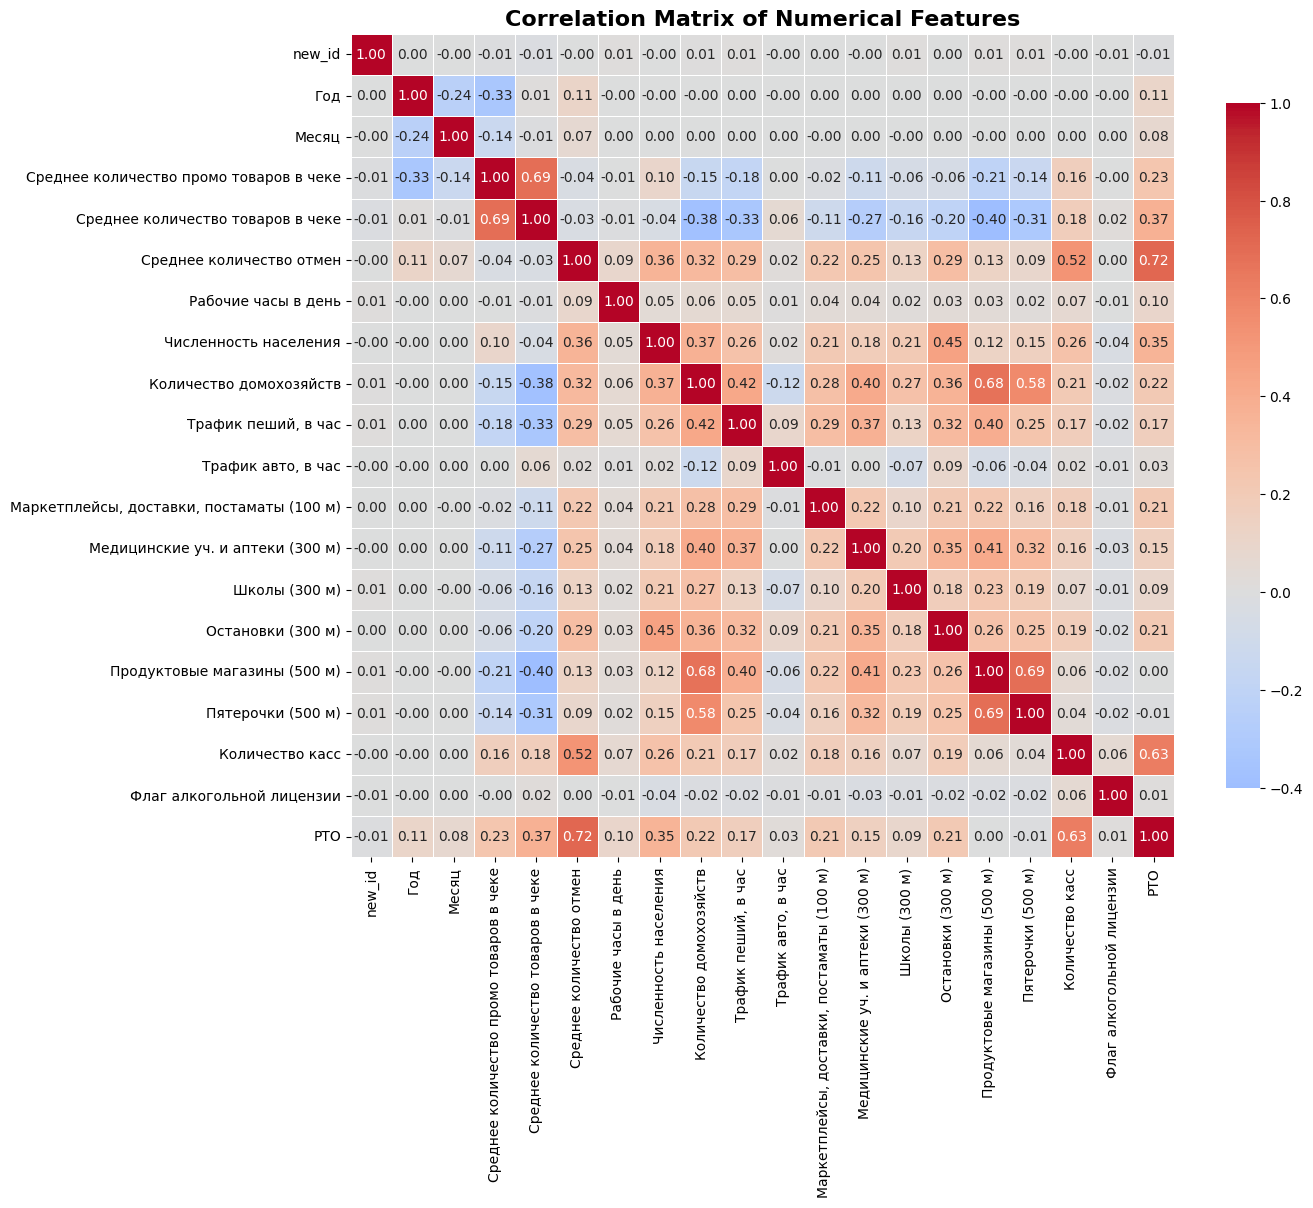

In [33]:
# Create correlation matrix for numerical features
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Create figure
fig, ax = plt.subplots(figsize=(14, 12))

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

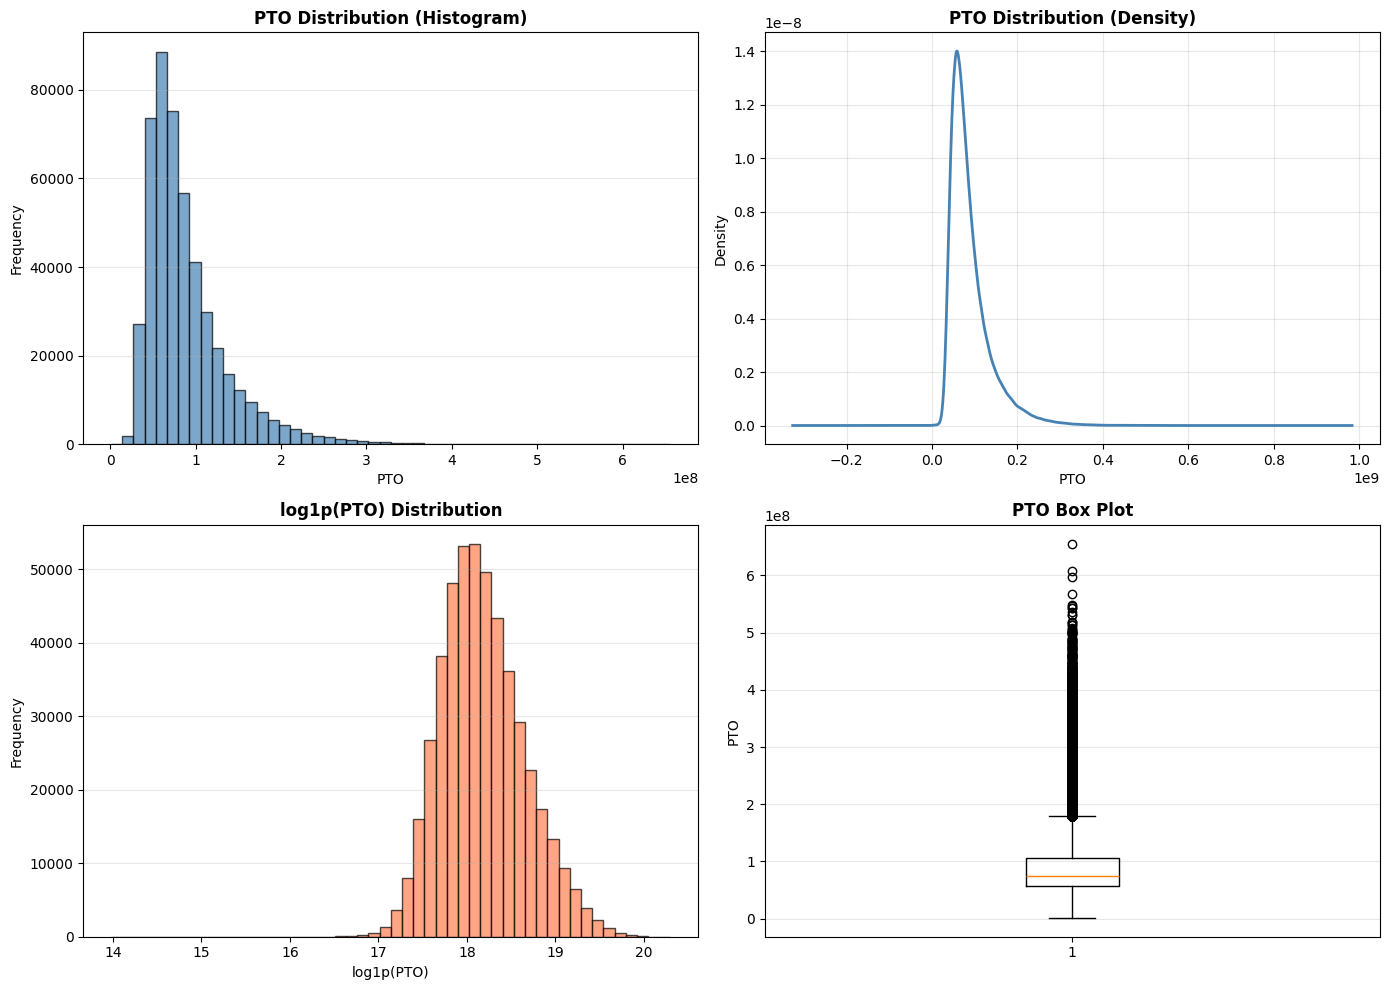

РТО Statistics:
Mean: 88534798.92
Median: 75210937.85
Std: 48248998.21
Min: 1179116.01
Max: 655720388.48
Skewness: 1.9860
Kurtosis: 5.9191

Quantiles:
0.25    5.627279e+07
0.50    7.521094e+07
0.75    1.057677e+08
0.90    1.499780e+08
0.95    1.850186e+08
0.99    2.653948e+08
Name: РТО, dtype: float64


In [34]:
import numpy as np
import seaborn as sns

# Distribution of РТО
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(df['РТО'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('РТО Distribution (Histogram)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('РТО')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(axis='y', alpha=0.3)

# Density plot
df['РТО'].dropna().plot(kind='density', ax=axes[0, 1], color='steelblue', linewidth=2)
axes[0, 1].set_title('РТО Distribution (Density)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('РТО')
axes[0, 1].grid(alpha=0.3)

# Log-scale histogram
axes[1, 0].hist(np.log1p(df['РТО'].dropna()), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_title('log1p(РТО) Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('log1p(РТО)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# Box plot
axes[1, 1].boxplot(df['РТО'].dropna(), vert=True)
axes[1, 1].set_title('РТО Box Plot', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('РТО')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("РТО Statistics:")
print(f"Mean: {df['РТО'].mean():.2f}")
print(f"Median: {df['РТО'].median():.2f}")
print(f"Std: {df['РТО'].std():.2f}")
print(f"Min: {df['РТО'].min():.2f}")
print(f"Max: {df['РТО'].max():.2f}")
print(f"Skewness: {df['РТО'].skew():.4f}")
print(f"Kurtosis: {df['РТО'].kurtosis():.4f}")
print(f"\nQuantiles:")
print(df['РТО'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

### 'РТО', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен' нестационарные

In [35]:
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Stationarity test for selected columns
test_columns = [
    'РТО', 
    'Среднее количество промо товаров в чеке', 
    'Среднее количество товаров в чеке', 
    'Среднее количество отмен'
]

print("="*80)
print("AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST - Per Store Time Series")
print("="*80)
print("Testing each store (new_id) separately, then aggregating results\n")

# Dictionary to store results per column
column_results = {col: {'stationary': 0, 'non_stationary': 0, 'error': 0} for col in test_columns}

# Test each store's time series
df_inflation_adjusted = pd.read_csv("../data/processed/v1.csv")
store_ids = df_inflation_adjusted['new_id'].unique()
print(f"Testing {len(store_ids)} stores...\n")

for col in test_columns:
    for store_id in store_ids:
        store_data = df_inflation_adjusted[df_inflation_adjusted['new_id'] == store_id].sort_values(['Год', 'Месяц'])[col].values
        
        if len(store_data) < 4:  # Need at least 4 observations
            continue
        
        try:
            adf_result = adfuller(store_data, autolag='AIC', maxlag=3)
            p_value = adf_result[1]
            
            if p_value < 0.05:
                column_results[col]['stationary'] += 1
            else:
                column_results[col]['non_stationary'] += 1
        except Exception as e:
            column_results[col]['error'] += 1

# Print results
print("\nStationarity Test Results (by Column):")
print("-" * 80)
print(f"{'Column':<50} {'Stationary':<15} {'Non-Stationary':<15}")
print("-" * 80)

for col in test_columns:
    stat = column_results[col]['stationary']
    non_stat = column_results[col]['non_stationary']
    total = stat + non_stat
    pct_stat = (stat / total * 100) if total > 0 else 0
    
    print(f"{col:<50} {stat:<15} {non_stat:<15}")
    print(f"{'  → Stationary percentage:':<50} {pct_stat:.1f}%")
    print()

print("="*80)
print("\nInterpretation:")
print("  - If >50% of stores have stationary series → likely stationary overall")
print("  - If <50% of stores have stationary series → likely non-stationary (trending)")
print("="*80)

AUGMENTED DICKEY-FULLER (ADF) STATIONARITY TEST - Per Store Time Series
Testing each store (new_id) separately, then aggregating results

Testing 18657 stores...



KeyboardInterrupt: 

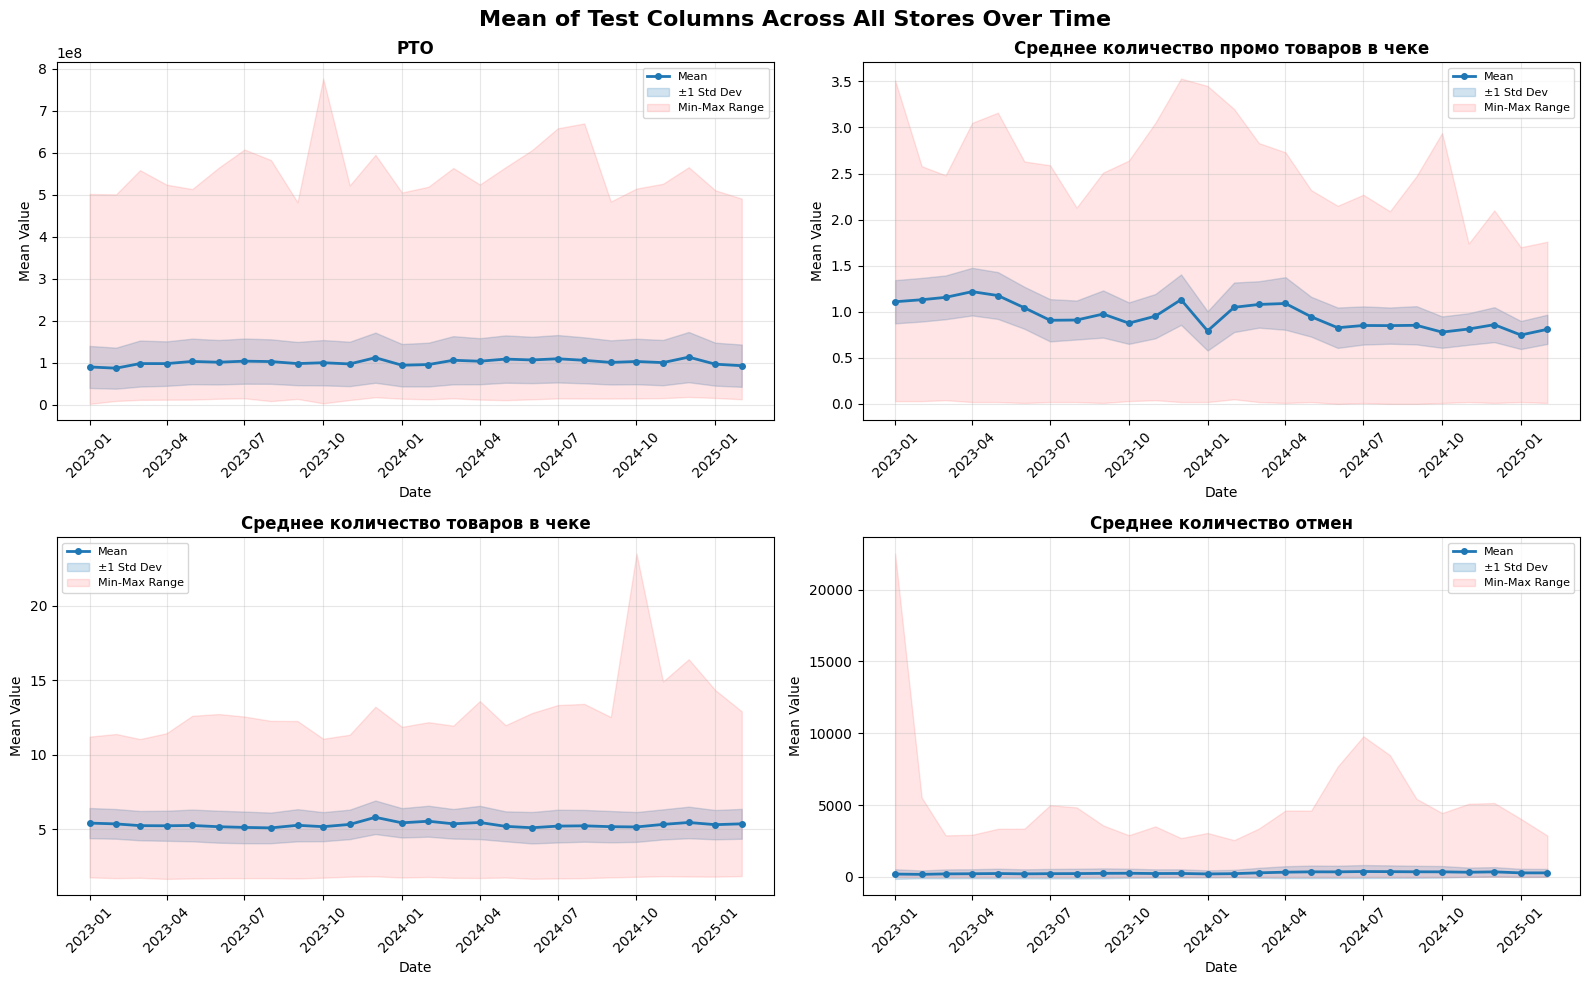


Summary Statistics for Test Columns Over Time

РТО:
  Mean (across all months): 100597686.15
  Std Dev: 6427952.01
  Min: 86545566.89 | Max: 112919053.78
  Change (first to last month): 2995205.61
  % Change: 3.3%

Среднее количество промо товаров в чеке:
  Mean (across all months): 0.96
  Std Dev: 0.14
  Min: 0.75 | Max: 1.22
  Change (first to last month): -0.30
  % Change: -27.0%

Среднее количество товаров в чеке:
  Mean (across all months): 5.28
  Std Dev: 0.16
  Min: 5.07 | Max: 5.79
  Change (first to last month): -0.05
  % Change: -0.9%

Среднее количество отмен:
  Mean (across all months): 273.60
  Std Dev: 62.73
  Min: 176.92 | Max: 375.37
  Change (first to last month): 84.89
  % Change: 43.3%


In [36]:
# Plot distribution of mean for test_columns across all stores over time
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Mean of Test Columns Across All Stores Over Time', fontsize=16, fontweight='bold')

# Create date column for x-axis
df_inflation_adjusted['Date'] = pd.to_datetime(df_inflation_adjusted[['Год', 'Месяц']].rename(columns={'Год': 'year', 'Месяц': 'month'}).assign(day=1))

axes = axes.flatten()

for idx, col in enumerate(test_columns):
    ax = axes[idx]
    
    # Calculate mean by month
    monthly_mean = df_inflation_adjusted.groupby('Date')[col].agg(['mean', 'std', 'min', 'max']).reset_index()
    
    # Plot mean line
    ax.plot(monthly_mean['Date'], monthly_mean['mean'], marker='o', linewidth=2, 
            label='Mean', color='#1f77b4', markersize=4)
    
    # Add confidence band (mean ± std)
    ax.fill_between(monthly_mean['Date'], 
                     monthly_mean['mean'] - monthly_mean['std'], 
                     monthly_mean['mean'] + monthly_mean['std'],
                     alpha=0.2, color='#1f77b4', label='±1 Std Dev')
    
    # Add min/max range
    ax.fill_between(monthly_mean['Date'], 
                     monthly_mean['min'], 
                     monthly_mean['max'],
                     alpha=0.1, color='red', label='Min-Max Range')
    
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Mean Value')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("Summary Statistics for Test Columns Over Time")
print("="*80)
for col in test_columns:
    monthly_mean = df_inflation_adjusted.groupby('Date')[col].mean()
    print(f"\n{col}:")
    print(f"  Mean (across all months): {monthly_mean.mean():.2f}")
    print(f"  Std Dev: {monthly_mean.std():.2f}")
    print(f"  Min: {monthly_mean.min():.2f} | Max: {monthly_mean.max():.2f}")
    print(f"  Change (first to last month): {monthly_mean.iloc[-1] - monthly_mean.iloc[0]:.2f}")
    print(f"  % Change: {((monthly_mean.iloc[-1] - monthly_mean.iloc[0]) / monthly_mean.iloc[0] * 100):.1f}%")

In [48]:
# Analyze shops with highest and lowest metrics
metrics = [
    'РТО',
    'Среднее количество товаров в чеке',
    'Среднее количество промо товаров в чеке',
    'Среднее количество отмен'
]

# Group by shop and calculate mean for each metric
shop_means = df.groupby('new_id')[metrics].mean().reset_index()

# Collect all shops and track which metrics they're extreme for
shops_to_show = set()
shop_metric_ranks = {}  # Maps shop_id to list of (metric, rank_type) tuples

for metric in metrics:
    top_2_highest = shop_means.nlargest(2, metric)['new_id'].tolist()
    top_2_lowest = shop_means.nsmallest(2, metric)['new_id'].tolist()
    
    # Track highest
    for shop_id in top_2_highest:
        shops_to_show.add(shop_id)
        if shop_id not in shop_metric_ranks:
            shop_metric_ranks[shop_id] = []
        shop_metric_ranks[shop_id].append(f"Highest {metric}")
    
    # Track lowest
    for shop_id in top_2_lowest:
        shops_to_show.add(shop_id)
        if shop_id not in shop_metric_ranks:
            shop_metric_ranks[shop_id] = []
        shop_metric_ranks[shop_id].append(f"Lowest {metric}")

shops_to_show = sorted(list(shops_to_show))

# Get all columns for these shops - for numeric, use mean; for categorical, take first value
agg_dict = {
    col: ('mean' if df[col].dtype in ['float64', 'int64'] else 'first')
    for col in df.columns if col != 'new_id'
}

result_df = df[df['new_id'].isin(shops_to_show)].groupby('new_id').agg(agg_dict).reset_index()

# Add column showing which metrics this shop is extreme for
result_df['Extreme Metrics'] = result_df['new_id'].map(
    lambda shop_id: '; '.join(shop_metric_ranks.get(shop_id, []))
)

# Sort by РТО for better visibility
# result_df = result_df.sort_values('РТО', ascending=False)

print("\n\nAll Features for Shops with Highest and Lowest Metrics (grouped by new_id):\n")
print(result_df.to_string())

# Add info about which ranks each shop has
print("\n\n" + "="*80)
print("Detailed breakdown by metric:")
print("="*80)
for metric in metrics:
    print(f"\n{metric}:")
    metric_sorted = shop_means.sort_values(metric, ascending=False).reset_index(drop=True)
    
    print(f"  Top 2 Highest:")
    for i in range(2):
        shop_id = metric_sorted.iloc[i]['new_id']
        value = metric_sorted.iloc[i][metric]
        print(f"    Rank {i+1}: Shop {int(shop_id)} - {value:.4f}")
    
    print(f"  Top 2 Lowest:")
    metric_sorted_asc = shop_means.sort_values(metric, ascending=True).reset_index(drop=True)
    for i in range(2):
        shop_id = metric_sorted_asc.iloc[i]['new_id']
        value = metric_sorted_asc.iloc[i][metric]
        print(f"    Rank {i+1}: Shop {int(shop_id)} - {value:.4f}")



All Features for Shops with Highest and Lowest Metrics (grouped by new_id):

    new_id          Год     Месяц  Среднее количество промо товаров в чеке  Среднее количество товаров в чеке  Среднее количество отмен  Рабочие часы в день Дата открытия, категориальный Торговая площадь, категориальный   Населенный пункт              Регион  Численность населения  Количество домохозяйств  Трафик пеший, в час  Трафик авто, в час  Маркетплейсы, доставки, постаматы (100 м)  Медицинские уч. и аптеки (300 м)  Школы (300 м)  Остановки (300 м)  Продуктовые магазины (500 м)  Пятерочки (500 м)  Количество касс  Флаг алкогольной лицензии           РТО                                                                                       Extreme Metrics
0     5884  2023.615385  6.115385                                 1.223846                           6.810385               1676.384615                 13.0                  Открыт давно                    Очень большой  Санкт-Петербург г   Санкт-Петерб

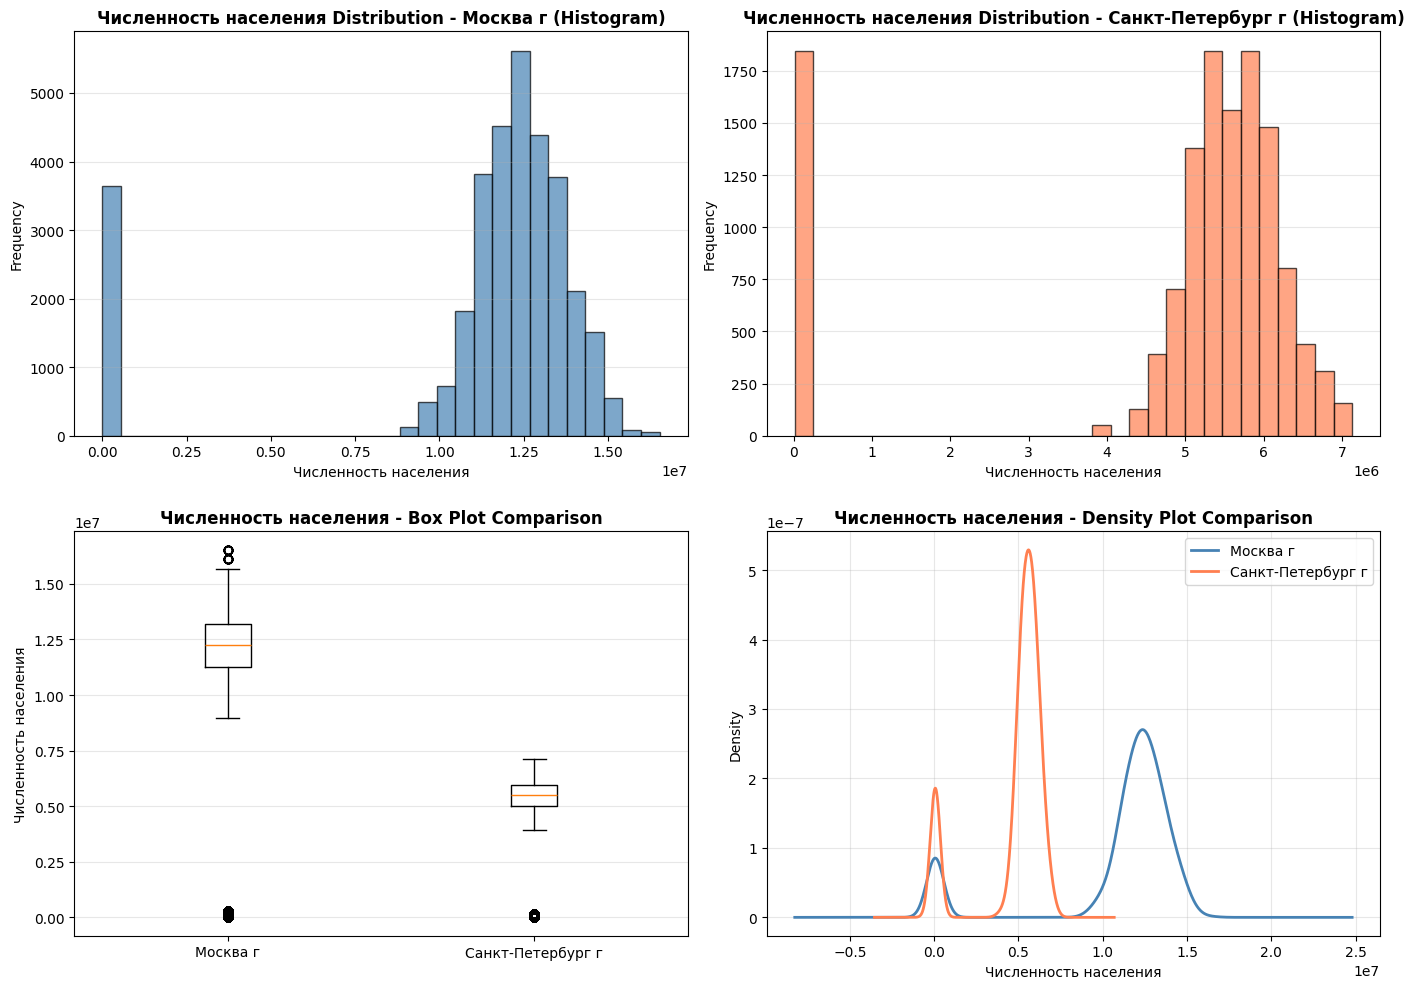


Summary Statistics for 'Численность населения'

Москва г:
  Count: 33228
  Mean: 11110266.24
  Median: 12252042.00
  Std: 4038094.68
  Min: 0.00
  Max: 16531571.00
  Quantiles (25%, 50%, 75%): [11243079. 12252042. 13177510.]

Санкт-Петербург г:
  Count: 12948
  Mean: 4841473.27
  Median: 5495826.50
  Std: 2011486.16
  Min: 16153.00
  Max: 7127958.00
  Quantiles (25%, 50%, 75%): [5015274.  5495826.5 5938214. ]



In [72]:
# Plot distribution of 'Численность населения' for Москва г and Санкт-петербург г
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

moscow_data = df[df['Регион'] == 'Москва г']['Численность населения'].dropna()
spb_data = df[df['Регион'] == 'Санкт-Петербург г']['Численность населения'].dropna()

# Histograms
axes[0, 0].hist(moscow_data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Численность населения Distribution - Москва г (Histogram)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Численность населения')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].hist(spb_data, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title('Численность населения Distribution - Санкт-Петербург г (Histogram)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Численность населения')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(axis='y', alpha=0.3)

# Box plots for comparison
box_data = [moscow_data, spb_data]
axes[1, 0].boxplot(box_data, labels=['Москва г', 'Санкт-Петербург г'], vert=True)
axes[1, 0].set_title('Численность населения - Box Plot Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Численность населения')
axes[1, 0].grid(axis='y', alpha=0.3)

# Density plots
moscow_data.plot(kind='density', ax=axes[1, 1], color='steelblue', linewidth=2, label='Москва г')
if len(spb_data) > 1 and spb_data.std() > 0:
    spb_data.plot(kind='density', ax=axes[1, 1], color='coral', linewidth=2, label='Санкт-Петербург г')
else:
    axes[1, 1].text(0.5, 0.5, 'Санкт-Петербург г: Insufficient data for density plot', 
                    ha='center', va='center', transform=axes[1, 1].transAxes, color='red')

axes[1, 1].set_title('Численность населения - Density Plot Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Численность населения')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("Summary Statistics for 'Численность населения'")
print("="*80)

print("\nМосква г:")
print(f"  Count: {len(moscow_data)}")
if len(moscow_data) > 0:
    print(f"  Mean: {moscow_data.mean():.2f}")
    print(f"  Median: {moscow_data.median():.2f}")
    print(f"  Std: {moscow_data.std():.2f}")
    print(f"  Min: {moscow_data.min():.2f}")
    print(f"  Max: {moscow_data.max():.2f}")
    print(f"  Quantiles (25%, 50%, 75%): {moscow_data.quantile([0.25, 0.5, 0.75]).values}")

print("\nСанкт-Петербург г:")
print(f"  Count: {len(spb_data)}")
if len(spb_data) > 0:
    print(f"  Mean: {spb_data.mean():.2f}")
    print(f"  Median: {spb_data.median():.2f}")
    print(f"  Std: {spb_data.std():.2f}")
    print(f"  Min: {spb_data.min():.2f}")
    print(f"  Max: {spb_data.max():.2f}")
    print(f"  Quantiles (25%, 50%, 75%): {spb_data.quantile([0.25, 0.5, 0.75]).values}")

print("\n" + "="*80)

In [71]:
print(f"Median SPB population: {df[df['Регион'] == 'Санкт-Петербург г']['Численность населения'].median()}")
print(f"Real SPB population 5645943")
print()

print(f"Median Moscow population: {df[df['Регион'] == 'Москва г']['Численность населения'].median()}")
print(f"Real Moscow population 13258262")

Median SPB population: 5495826.5
Real SPB population 5645943

Median Moscow population: 12252042.0
Real Moscow population 13258262


## TODO
1) Сделать поправку на инфляцию
2) Сделать энкодинг категориальных фитч
3) Убрать аномалии
4) Что такое Количество домохозяйств?